# Usage of PySpark SQL

In [7]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
                     .appName("Analyzing an unknown article.")
                     .getOrCreate())


In [8]:
## documentation
spark.read??

In [9]:
file_path = r'skull.txt' # fill in

In [10]:
article = spark.read.text(file_path)

In [11]:
article.show(5, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [12]:
from pyspark.sql.functions import col

In [13]:

article.select(article.value)
article.select(article['value'])
article.select(col('value'))
article.select('value')

DataFrame[value: string]

In [14]:
from pyspark.sql.functions import col, split
lines = article.select(split(col('value'), ' ').alias('line'))
lines.show(5, truncate=False)


+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|line                                                                                                                                                                                                                                                                                                                                                                                                                  

In [15]:
from pyspark.sql.functions import explode
words = lines.select(explode(col('line')).alias('word'))
words.show(5)

+----+
|word|
+----+
|  If|
| you|
|look|
|  at|
|   a|
+----+
only showing top 5 rows


In [16]:
from pyspark.sql.functions import lower
words_lower = words.select(lower(col('word')).alias('word'))
words_lower.show(5)

+----+
|word|
+----+
|  if|
| you|
|look|
|  at|
|   a|
+----+
only showing top 5 rows


In [17]:
from pyspark.sql.functions import regexp_extract, col

word_clean = words_lower.select(
    regexp_extract(col('word'), r'(\W+)?([a-z]+)', 2).alias('word')
)

word_clean.show(5)

+----+
|word|
+----+
|  if|
| you|
|look|
|  at|
|   a|
+----+
only showing top 5 rows


In [18]:
words_nonnull = word_clean.filter(col('word') != '')
words_nonnull.show(5)

+----+
|word|
+----+
|  if|
| you|
|look|
|  at|
|   a|
+----+
only showing top 5 rows


In [19]:
groups = words_nonnull.groupBy(col('word'))

In [20]:
counts = groups.count()
counts.show(5)

+------+-----+
|  word|count|
+------+-----+
| those|    4|
|  some|    7|
| inner|    2|
|   art|    1|
|filled|    1|
+------+-----+
only showing top 5 rows


In [21]:
counts.orderBy(col('count').desc()).show()

+------------+-----+
|        word|count|
+------------+-----+
|         the|   49|
|          of|   42|
|         and|   41|
|          to|   30|
|        that|   29|
|           a|   23|
|       brain|   22|
|         our|   15|
|        size|   15|
|          in|   14|
|        they|   13|
|neanderthals|   13|
|       about|   12|
| differences|   12|
|      brains|   12|
|          we|   12|
|     species|    9|
|        with|    9|
|          it|    9|
|   cognitive|    9|
+------------+-----+
only showing top 20 rows


Exercise

In [23]:
# Task 1 - top 5 filtered words by occurence frequencies
from pyspark.sql.functions import length

long_words = word_clean.filter(length(col('word')) > 5)
long_words.groupBy(col('word')).count().orderBy(col('count').desc()).show(5)

+------------+-----+
|        word|count|
+------------+-----+
|neanderthals|   13|
| differences|   12|
|      brains|   12|
|   cognitive|    9|
|     species|    9|
+------------+-----+
only showing top 5 rows


In [26]:
# Task 2 - Table of word lengths and occurence frequencies
words_len = long_words.groupBy(length(col('word')).alias('word_length')).count().orderBy('word_length')
words_len.show()

+-----------+-----+
|word_length|count|
+-----------+-----+
|          6|   98|
|          7|   92|
|          8|   43|
|          9|   50|
|         10|   37|
|         11|   46|
|         12|   22|
|         13|    2|
|         14|    2|
|         15|    2|
|         16|    2|
|         19|    1|
+-----------+-----+



In [28]:
# Task 3 - histogram of the occurences of each alphabet (highest to lowest usage)
import matplotlib.pyplot as plt

letter_counts = (words_nonnull.select(explode(split(col('word'), '')).alias('letter')).filter(col('letter') != '')
.groupBy(col('letter')).count().orderBy(col('count').desc()))

letter_counts.show(26)

+------+-----+
|letter|count|
+------+-----+
|     e|  745|
|     a|  529|
|     t|  506|
|     n|  471|
|     o|  448|
|     i|  406|
|     s|  389|
|     r|  362|
|     h|  291|
|     l|  253|
|     d|  211|
|     c|  205|
|     u|  182|
|     m|  154|
|     f|  123|
|     p|  115|
|     b|  114|
|     g|  113|
|     w|   93|
|     y|   87|
|     v|   55|
|     k|   36|
|     z|   19|
|     x|    7|
|     q|    4|
|     j|    4|
+------+-----+



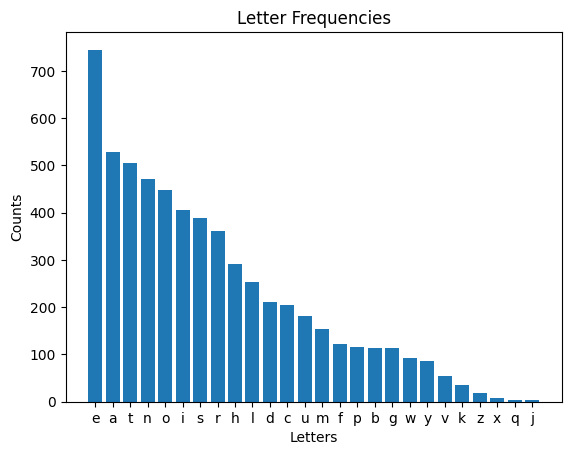

In [31]:
# Sketching the histogram
data_for_hist = letter_counts.collect()
letters = [i['letter'] for i in data_for_hist]
counts = [i['count'] for i in data_for_hist]

plt.bar(letters, counts)
plt.xlabel('Letters')
plt.ylabel('Counts')
plt.title('Letter Frequencies')
plt.show()